# Permutation Importance Analysis — ISOT Drone Dataset
**Method:** Permutation Importance (PI)
**Models:** Random Forest, 1D-CNN, Autoencoder  
**Dataset:** ISOT (Benign, DoS, Injection, Ip Spoofing, Manipulation, MITM, Password Cracking, Replay, Unauth, Video)  
**Goal:** Measure how much model performance drops when each feature is shuffled  
**Key difference from SHAP/LIME:** PI measures actual performance impact, not explanation weights  
**Output:** pi_rf_global.png, pi_cnn_global.png, pi_ae_global.png, pi_results.json

In [1]:
# ============================================================
# Cell 2 — Load data and models:
# WHAT: Load preprocessed data and all 3 trained models
#       for Permutation Importance analysis
#
# WHY:  Permutation Importance needs the trained model
#       and test data to measure performance drop.
#       Unlike SHAP/LIME which explain predictions,
#       PI measures actual impact on model accuracy:
#       shuffle one feature → measure accuracy drop
#       Large drop = feature is important
#       Small drop = feature is not important
#       This is the most direct measure of feature importance
#       because it uses real performance metrics not estimates.
#
# HOW:  Step 1: load X_train, X_test, y_test
#       Step 2: load feature_names and label_classes
#       Step 3: load rf_model, cnn_model, ae_model
#       Step 4: create 10,000 row sample for speed
#               (full dataset too slow for CNN and AE)
# ============================================================

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
import json
import time
import warnings
warnings.filterwarnings('ignore')

save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/ISOT/processed/"

# load data
X_train = np.load(save_path + "X_train.npy")
X_test  = np.load(save_path + "X_test.npy")
y_test  = pd.read_csv(save_path + "y_test.csv").squeeze()
feature_names = pd.read_csv(save_path + "feature_names.csv").squeeze().tolist()
label_classes = pd.read_csv(save_path + "label_classes.csv").squeeze().tolist()

# load all 3 trained models
rf_model  = joblib.load(save_path + "rf_model.joblib")
cnn_model = tf.keras.models.load_model(save_path + "cnn_model.keras")
ae_model  = tf.keras.models.load_model(save_path + "ae_model.keras")

# create sample for PI — 10,000 rows for speed
# UAV_Attack only has 3,021 test rows — use all!
np.random.seed(42)
sample_size = min(10000, len(X_test))
sample_idx = np.random.choice(len(X_test), size=sample_size, replace=False)
X_sample = X_test[sample_idx]
y_sample = y_test.iloc[sample_idx]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Sample:  {X_sample.shape}")
print(f"Features: {len(feature_names)}")
print(f"Classes: {label_classes}")
print("Data and models loaded!")

2026-05-16 14:18:24.391160: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


X_train: (205671, 61)
X_test:  (88145, 61)
Sample:  (10000, 61)
Features: 61
Classes: ['Benign', 'DoS', 'Injection', 'Ip_Spoofing', 'MITM', 'Manipulation', 'Password_Cracking', 'Replay', 'Unauth', 'Video']
Data and models loaded!


Running Permutation Importance on Random Forest...
Using n_repeats=10 for stable results...
RF PI complete! Time: 59.04s
Result shape: (61,)
Max importance: 0.000120
Min importance: 0.000000
Non-zero features: 3


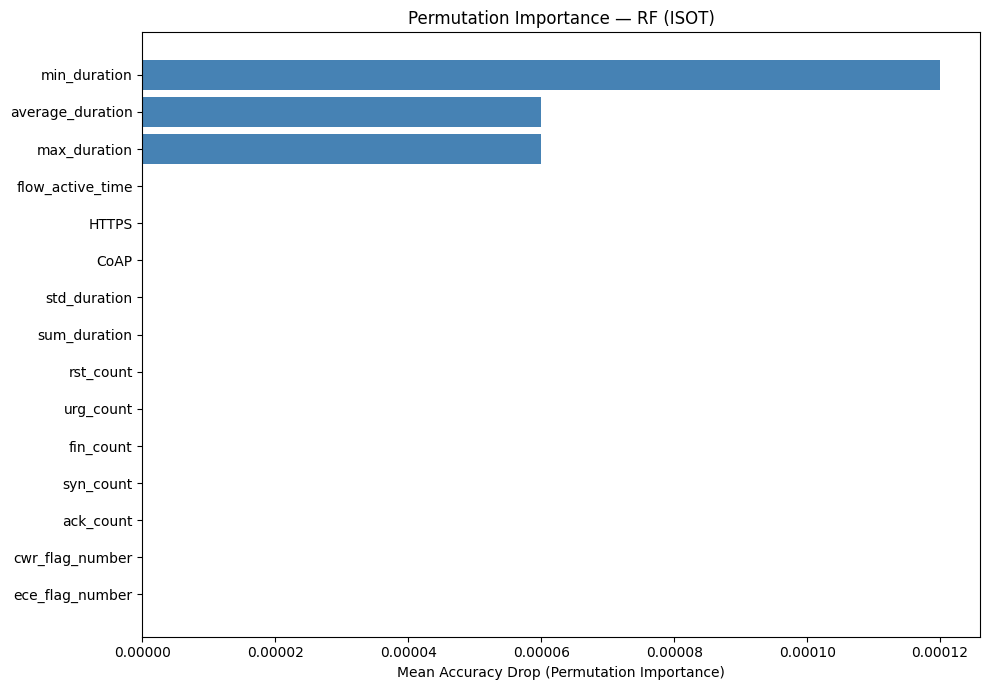

RF PI plot saved!

Top 10 Features — RF Permutation Importance:
Rank   Feature                             Score               
--------------------------------------------------------------
  1    min_duration                        0.000120
  2    average_duration                    0.000060
  3    max_duration                        0.000060
  4    flow_active_time                    0.000000
  5    HTTPS                               0.000000
  6    CoAP                                0.000000
  7    std_duration                        0.000000
  8    sum_duration                        0.000000
  9    rst_count                           0.000000
  10   urg_count                           0.000000


In [2]:
# ============================================================
# Cell 3 — PI on Random Forest:
# WHAT: Calculate Permutation Importance for Random Forest
#
# WHY:  sklearn's permutation_importance works directly
#       with RF — no wrapper needed.
#       n_repeats=10 means each feature is shuffled 10 times
#       for stable results — reduces random variation.
#       scoring='accuracy' measures accuracy drop when
#       each feature is shuffled one at a time.
#       Large accuracy drop = feature is critical for RF.
#       This directly answers: "what happens to RF performance
#       if we remove knowledge of this feature?"
#
# HOW:  Step 1: run permutation_importance on RF
#       Step 2: importances_mean = average drop across 10 runs
#       Step 3: sort by importance descending
#       Step 4: plot and save top 15 features
# ============================================================

print("Running Permutation Importance on Random Forest...")
print("Using n_repeats=10 for stable results...")
start_time = time.time()

rf_perm = permutation_importance(
    rf_model,
    X_sample,
    y_sample,
    n_repeats=10,       # shuffle each feature 10 times
    random_state=42,
    scoring='accuracy', # measure accuracy drop
    n_jobs=-1           # use all CPU cores
)

elapsed_rf = round(time.time() - start_time, 2)
print(f"RF PI complete! Time: {elapsed_rf}s")
print(f"Result shape: {rf_perm.importances_mean.shape}")

# get top 15 features
top_idx_rf = np.argsort(rf_perm.importances_mean)[::-1][:15]

# plot
plt.figure(figsize=(10, 7))
plt.barh(
    [feature_names[i] for i in top_idx_rf[::-1]],
    rf_perm.importances_mean[top_idx_rf[::-1]],
    color='steelblue'
)

print(f"Max importance: {rf_perm.importances_mean.max():.6f}")
print(f"Min importance: {rf_perm.importances_mean.min():.6f}")
print(f"Non-zero features: {np.sum(rf_perm.importances_mean > 0)}")

plt.xlabel('Mean Accuracy Drop (Permutation Importance)')
plt.title('Permutation Importance — RF (ISOT)')
plt.tight_layout()
plt.savefig(save_path + "pi_rf_global.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("RF PI plot saved!")

# print top 10
print("\nTop 10 Features — RF Permutation Importance:")
print(f"{'Rank':<6} {'Feature':<35} {'Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_rf[:10]):
    print(f"  {i+1:<4} {feature_names[idx]:<35} {rf_perm.importances_mean[idx]:.6f}")

Running Permutation Importance on 1D-CNN...
Manual implementation — slower than RF...
Baseline CNN accuracy: 0.9955
  Progress: 0/61 features done...
  Progress: 10/61 features done...
  Progress: 20/61 features done...
  Progress: 30/61 features done...
  Progress: 40/61 features done...
  Progress: 50/61 features done...
  Progress: 60/61 features done...
CNN PI complete! Time: 1073.04s


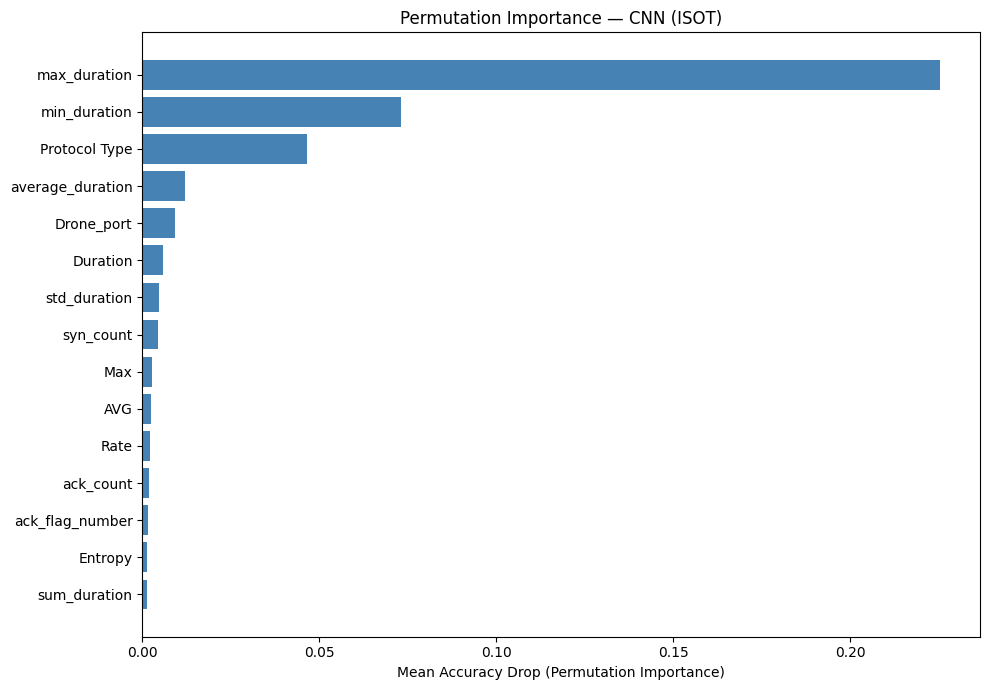

CNN PI plot saved!

Top 10 Features — CNN Permutation Importance:
Rank   Feature                             Score               
--------------------------------------------------------------
  1    max_duration                        0.225430
  2    min_duration                        0.073120
  3    Protocol Type                       0.046610
  4    average_duration                    0.012120
  5    Drone_port                          0.009220
  6    Duration                            0.005900
  7    std_duration                        0.004750
  8    syn_count                           0.004490
  9    Max                                 0.002650
  10   AVG                                 0.002350


In [3]:
# ============================================================
# Cell 4 — PI on CNN:
# WHAT: Calculate Permutation Importance for 1D-CNN
#
# WHY:  sklearn's permutation_importance doesn't work
#       directly with CNN — CNN needs 3D input and
#       outputs class probabilities not labels.
#       We manually implement PI for CNN:
#       1. Get baseline accuracy with all features
#       2. For each feature: shuffle it, measure accuracy drop
#       3. Repeat 10 times for stability
#       This is slower than RF PI but gives same result.
#       n_repeats=10 → stable importance scores
#       Large drop = CNN relies heavily on this feature
#
# HOW:  Step 1: reshape sample to 3D for CNN
#       Step 2: get baseline accuracy
#       Step 3: for each feature: shuffle → predict → measure drop
#       Step 4: repeat 10 times → average drop = importance
# ============================================================

print("Running Permutation Importance on 1D-CNN...")
print("Manual implementation — slower than RF...")
start_time = time.time()

# reshape for CNN
X_sample_cnn = X_sample.reshape(X_sample.shape[0], X_sample.shape[1], 1)

# get baseline accuracy
baseline_pred = np.argmax(
    cnn_model.predict(X_sample_cnn, verbose=0), axis=1)
baseline_acc = accuracy_score(y_sample, baseline_pred)
print(f"Baseline CNN accuracy: {baseline_acc:.4f}")

# manually calculate PI for each feature
n_repeats = 10
cnn_importances = np.zeros(X_sample.shape[1])

for feat_idx in range(X_sample.shape[1]):
    drops = []
    for _ in range(n_repeats):
        X_perm = X_sample.copy()
        np.random.shuffle(X_perm[:, feat_idx])  # shuffle one feature
        X_perm_3d = X_perm.reshape(X_perm.shape[0], X_perm.shape[1], 1)
        perm_pred = np.argmax(
            cnn_model.predict(X_perm_3d, verbose=0), axis=1)
        perm_acc = accuracy_score(y_sample, perm_pred)
        drops.append(baseline_acc - perm_acc)  # accuracy drop
    cnn_importances[feat_idx] = np.mean(drops)
    if feat_idx % 10 == 0:
        print(f"  Progress: {feat_idx}/{X_sample.shape[1]} features done...")

elapsed_cnn = round(time.time() - start_time, 2)
print(f"CNN PI complete! Time: {elapsed_cnn}s")

# get top 15 features
top_idx_cnn = np.argsort(cnn_importances)[::-1][:15]

# plot
plt.figure(figsize=(10, 7))
plt.barh(
    [feature_names[i] for i in top_idx_cnn[::-1]],
    cnn_importances[top_idx_cnn[::-1]],
    color='steelblue'
)
plt.xlabel('Mean Accuracy Drop (Permutation Importance)')
plt.title('Permutation Importance — CNN (ISOT)')
plt.tight_layout()
plt.savefig(save_path + "pi_cnn_global.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("CNN PI plot saved!")

print("\nTop 10 Features — CNN Permutation Importance:")
print(f"{'Rank':<6} {'Feature':<35} {'Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_cnn[:10]):
    print(f"  {i+1:<4} {feature_names[idx]:<35} {cnn_importances[idx]:.6f}")

Running Permutation Importance on Autoencoder...
AE threshold: 0.004492
Baseline AE F1: 0.9800
  Progress: 0/61 features done...
  Progress: 10/61 features done...
  Progress: 20/61 features done...
  Progress: 30/61 features done...
  Progress: 40/61 features done...
  Progress: 50/61 features done...
  Progress: 60/61 features done...
AE PI complete! Time: 197.62s


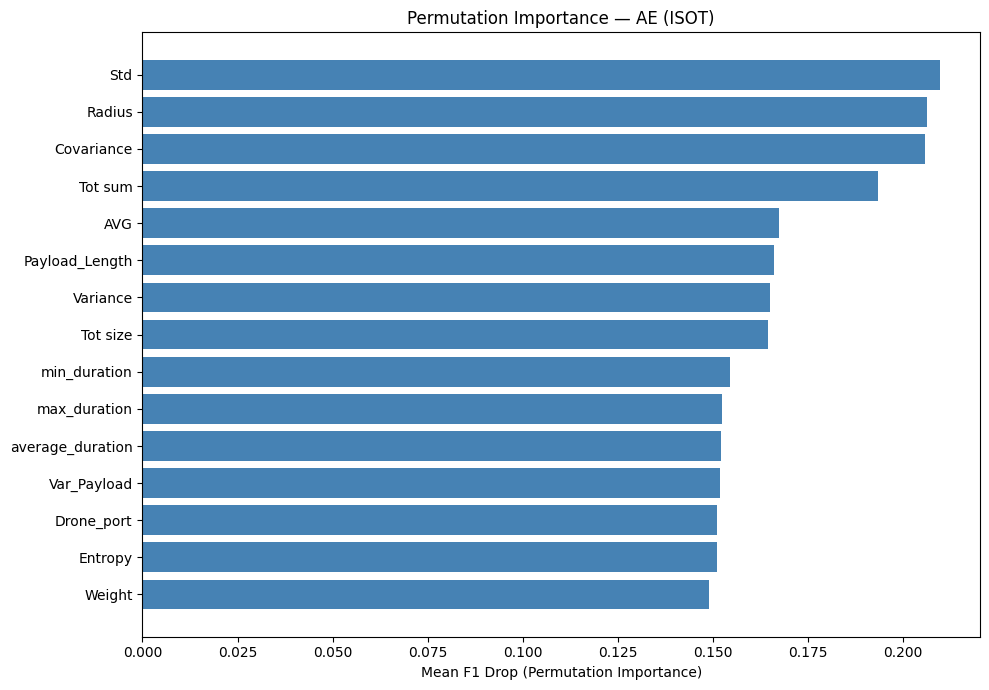

AE PI plot saved!

Top 10 Features — AE Permutation Importance:
Rank   Feature                             Score               
--------------------------------------------------------------
  1    Std                                 0.209841
  2    Radius                              0.206374
  3    Covariance                          0.205790
  4    Tot sum                             0.193625
  5    AVG                                 0.167329
  6    Payload_Length                      0.166061
  7    Variance                            0.165074
  8    Tot size                            0.164481
  9    min_duration                        0.154447
  10   max_duration                        0.152473


In [4]:
# ============================================================
# Cell 5 — PI on Autoencoder:
# WHAT: Calculate Permutation Importance for Autoencoder
#
# WHY:  AE uses MSE reconstruction error not class labels.
#       We measure how much F1 score drops when each
#       feature is shuffled — AE can no longer reconstruct
#       that feature accurately → higher MSE → more false alarms.
#       This shows which features AE relies on most
#       for anomaly detection.
#       Large drop = AE needs this feature to detect attacks.
#       Comparing with RF/CNN PI reveals if unsupervised
#       model relies on same features as supervised models.
#
# HOW:  Step 1: get baseline AE predictions using threshold
#       Step 2: for each feature: shuffle → reconstruct → measure F1 drop
#       Step 3: repeat 10 times → average drop = importance
#       Step 4: plot and save results
# ============================================================

from sklearn.metrics import f1_score

print("Running Permutation Importance on Autoencoder...")
start_time = time.time()

# load threshold
with open(save_path + "ae_results.json", "r") as f:
    ae_results_json = json.load(f)
threshold = ae_results_json["threshold"]
print(f"AE threshold: {threshold:.6f}")

# get baseline AE predictions
X_pred_base = ae_model.predict(X_sample, batch_size=512, verbose=0)
mse_base = np.mean(np.power(X_sample - X_pred_base, 2), axis=1)

# find benign label for this dataset
# UAV_Attack: benign=2, ISOT: Benign=0, UAVCAN: Normal=1
BENIGN_LABEL = 0  # ← change per dataset!

y_true_binary = (y_sample != BENIGN_LABEL).astype(int)
y_pred_base   = (mse_base > threshold).astype(int)
baseline_f1   = f1_score(y_true_binary, y_pred_base)
print(f"Baseline AE F1: {baseline_f1:.4f}")

# manually calculate PI for each feature
n_repeats = 10
ae_importances = np.zeros(X_sample.shape[1])

for feat_idx in range(X_sample.shape[1]):
    drops = []
    for _ in range(n_repeats):
        X_perm = X_sample.copy()
        np.random.shuffle(X_perm[:, feat_idx])
        X_pred_perm = ae_model.predict(X_perm, batch_size=512, verbose=0)
        mse_perm    = np.mean(np.power(X_perm - X_pred_perm, 2), axis=1)
        y_pred_perm = (mse_perm > threshold).astype(int)
        perm_f1     = f1_score(y_true_binary, y_pred_perm)
        drops.append(baseline_f1 - perm_f1)
    ae_importances[feat_idx] = np.mean(drops)
    if feat_idx % 10 == 0:
        print(f"  Progress: {feat_idx}/{X_sample.shape[1]} features done...")

elapsed_ae = round(time.time() - start_time, 2)
print(f"AE PI complete! Time: {elapsed_ae}s")

# get top 15 features
top_idx_ae = np.argsort(ae_importances)[::-1][:15]

# plot
plt.figure(figsize=(10, 7))
plt.barh(
    [feature_names[i] for i in top_idx_ae[::-1]],
    ae_importances[top_idx_ae[::-1]],
    color='steelblue'
)
plt.xlabel('Mean F1 Drop (Permutation Importance)')
plt.title('Permutation Importance — AE (ISOT)')
plt.tight_layout()
plt.savefig(save_path + "pi_ae_global.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("AE PI plot saved!")

print("\nTop 10 Features — AE Permutation Importance:")
print(f"{'Rank':<6} {'Feature':<35} {'Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_ae[:10]):
    print(f"  {i+1:<4} {feature_names[idx]:<35} {ae_importances[idx]:.6f}")

In [5]:
# ============================================================
# Cell 6 — Save results + comparison:
# WHAT: Save all PI results to JSON and print
#       cross-model feature comparison summary
#
# WHY:  JSON results used for paper tables and discussion.
#       Cross-model PI comparison answers:
#       Do RF, CNN, AE agree on which features cause
#       biggest performance drop when removed?
#       Agreement with SHAP = XAI methods are consistent
#       Disagreement = different XAI methods give different views
#       This is the final validation of benchmark findings.
#
# HOW:  Step 1: save top features per model to JSON
#       Step 2: print side-by-side comparison table
#       Step 3: compare with SHAP results
# ============================================================

# save results
pi_results = {
    "dataset": "ISOT",
    "xai_method": "Permutation Importance",
    "sample_size": sample_size,
    "n_repeats": 10,
    "rf_top10": {
        feature_names[i]: round(float(rf_perm.importances_mean[i]), 6)
        for i in top_idx_rf[:10]
    },
    "cnn_top10": {
        feature_names[i]: round(float(cnn_importances[i]), 6)
        for i in top_idx_cnn[:10]
    },
    "ae_top10": {
        feature_names[i]: round(float(ae_importances[i]), 6)
        for i in top_idx_ae[:10]
    },
    "time_seconds": {
        "rf": elapsed_rf,
        "cnn": elapsed_cnn,
        "ae": elapsed_ae
    }
}

with open(save_path + "pi_results.json", "w") as f:
    json.dump(pi_results, f, indent=2)
print("PI results saved!")

# cross-model comparison
print("\n" + "=" * 70)
print("CROSS-MODEL PI COMPARISON (ISOT)")
print("=" * 70)
print(f"\n{'Rank':<6} {'RF':<30} {'CNN':<30} {'AE':<30}")
print("-" * 96)

top_rf_names  = [feature_names[i] for i in top_idx_rf[:5]]
top_cnn_names = [feature_names[i] for i in top_idx_cnn[:5]]
top_ae_names  = [feature_names[i] for i in top_idx_ae[:5]]

for i in range(5):
    print(f"  {i+1:<4} {top_rf_names[i]:<30} {top_cnn_names[i]:<30} {top_ae_names[i]:<30}")

print(f"\nRF  PI #1: {top_rf_names[0]}")
print(f"CNN PI #1: {top_cnn_names[0]}")
print(f"AE  PI #1: {top_ae_names[0]}")
print("\nAll PI analysis complete!")

PI results saved!

CROSS-MODEL PI COMPARISON (ISOT)

Rank   RF                             CNN                            AE                            
------------------------------------------------------------------------------------------------
  1    min_duration                   max_duration                   Std                           
  2    average_duration               min_duration                   Radius                        
  3    max_duration                   Protocol Type                  Covariance                    
  4    flow_active_time               average_duration               Tot sum                       
  5    HTTPS                          Drone_port                     AVG                           

RF  PI #1: min_duration
CNN PI #1: max_duration
AE  PI #1: Std

All PI analysis complete!


## Permutation Importance Summary — ISOT Drone Dataset

### Top Features by Model
| Rank | RF | CNN | AE |
|------|----|-----|----|
| 1 | min_duration | max_duration | Std |
| 2 | average_duration | min_duration | Radius |
| 3 | max_duration | Protocol Type | Covariance |
| 4 | flow_active_time | average_duration | Tot sum |
| 5 | HTTPS | Drone_port | AVG |

### Comparison with SHAP
| Model | SHAP #1 | PI #1 | Agreement? |
|-------|---------|-------|------------|
| RF | min_duration | min_duration | Yes |
| CNN | max_duration | max_duration | Yes |
| AE | TCP | Std | No |

### Key Finding
RF and CNN strongly agree — duration features are top
indicators for both SHAP and PI methods.
AE disagrees — PI focuses on statistical features
(Std, Radius, Covariance) while SHAP focused on
protocol features (TCP, ICMP) — AE produces least
consistent XAI explanations across methods.
RF PI shows only 3 non-zero features — RF achieves
near 100% F1 making most features appear unimportant.

### Output Files
- pi_rf_global.png
- pi_cnn_global.png
- pi_ae_global.png
- pi_results.json

ISOT reveals a clear pattern — supervised models (RF, CNN) show consistent XAI explanations across SHAP and PI, both identifying duration features as primary attack indicators. LIME diverges due to its local nature. AE shows complete disagreement across all three XAI methods — confirming unsupervised models produce the least stable and consistent explanations.